Distribution Analysis Results:
Mean: 100.56
Standard Deviation: 15.05
Percentage within 1σ: 69.8%
Percentage within 2σ: 94.2%
Percentage within 3σ: 99.7%
Probability of value < μ + 1σ: 0.841


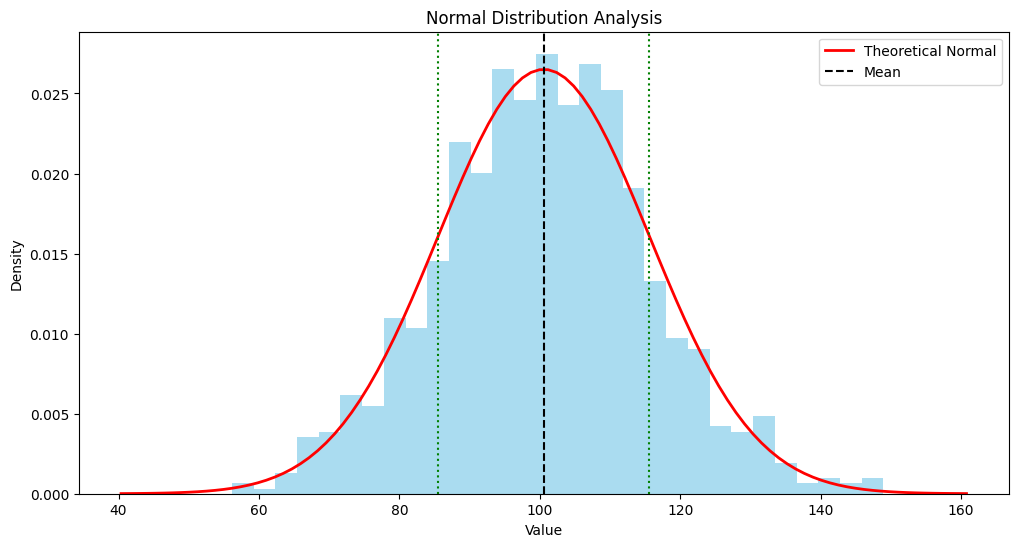

In [1]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

def demonstrate_normal_distribution():
    """
    Demonstrates key concepts of Normal Distribution in programming contexts.
    Shows generation, analysis, and visualization of normally distributed data.
    """
    # 1. Generating normally distributed data
    # Generate 1000 samples with mean=100 and std=15
    samples = np.random.normal(loc=100, scale=15, size=1000)
    
    # 2. Analyzing the distribution
    mean = np.mean(samples)
    std = np.std(samples)
    
    # 3. Calculate empirical rule boundaries
    one_sigma = (mean - std, mean + std)
    two_sigma = (mean - 2*std, mean + 2*std)
    three_sigma = (mean - 3*std, mean + 3*std)
    
    # 4. Calculate actual percentages within each boundary
    within_one = np.mean(np.abs(samples - mean) <= std) * 100
    within_two = np.mean(np.abs(samples - mean) <= 2 * std) * 100
    within_three = np.mean(np.abs(samples - mean) <= 3 * std) * 100
    
    # 5. Transform to standard normal (z-scores)
    z_scores = stats.zscore(samples)
    
    # 6. Calculate probabilities using cumulative distribution function (CDF)
    # Example: Probability of value being less than mean + 1 std
    prob_less_than_one_sigma = stats.norm.cdf(mean+std, loc=mean, scale=std)
    
    # 7. Visualization
    plt.figure(figsize=(12, 6))
    
    # Create histogram of original data
    plt.hist(samples, bins=30, density=True, alpha=0.7, color='skyblue')
    
    # Add theoretical normal curve
    x = np.linspace(mean - 4*std, mean + 4*std, 100)
    plt.plot(x, stats.norm.pdf(x, mean, std), 'r-', lw=2, 
             label='Theoretical Normal')
    
    # Add vertical lines for standard deviations
    plt.axvline(mean, color='black', linestyle='--', label='Mean')
    plt.axvline(one_sigma[0], color='green', linestyle=':')
    plt.axvline(one_sigma[1], color='green', linestyle=':')
    
    plt.title('Normal Distribution Analysis')
    plt.xlabel('Value')
    plt.ylabel('Density')
    plt.legend()
    
    return {
        'mean': mean,
        'std': std,
        'within_one_sigma': within_one,
        'within_two_sigma': within_two,
        'within_three_sigma': within_three,
        'prob_less_than_one_sigma': prob_less_than_one_sigma
    }

# Run the demonstration
results = demonstrate_normal_distribution()

# Print analysis results
print(f"Distribution Analysis Results:")
print(f"Mean: {results['mean']:.2f}")
print(f"Standard Deviation: {results['std']:.2f}")
print(f"Percentage within 1σ: {results['within_one_sigma']:.1f}%")
print(f"Percentage within 2σ: {results['within_two_sigma']:.1f}%")
print(f"Percentage within 3σ: {results['within_three_sigma']:.1f}%")
print(f"Probability of value < μ + 1σ: {results['prob_less_than_one_sigma']:.3f}")